### E-commerce Data Visualization Project

#### Code (Libraries & Data Generation)

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Setting seed for reproducibility
np.random.seed(42)
dates = pd.date_range(start="2026-01-01", periods=100, freq='D')
categories = ['Electronics', 'Clothing', 'Home Decor', 'Books']

# Creating the base DataFrame
df = pd.DataFrame({
    'Date': np.random.choice(dates, 500),
    'Category': np.random.choice(categories, 500),
    'Sales': np.random.randint(100, 1500, 500),
    'Profit': np.random.randint(-200, 600, 500),
    'Customer_Age': np.random.normal(35, 10, 500).astype(int),
    'Discount': np.random.uniform(0, 0.3, 500)
})
df['Date'] = pd.to_datetime(df['Date'])

# Aggregating data for trend and categorical analysis
df_trend = df.groupby('Date')[['Sales', 'Profit']].sum().reset_index().sort_values('Date')
df_cat = df.groupby('Category')['Sales'].sum().reset_index()

# Verifying the data structure
df.head()

,Date,Category,Sales,Profit,Customer_Age,Discount
0,2026-02-21,Books,1083,476,38,0.048254
1,2026-04-03,Clothing,168,-48,34,0.167413
2,2026-01-15,Books,645,177,44,0.243526
3,2026-03-13,Home Decor,152,387,47,0.222514
4,2026-03-02,Electronics,304,398,37,0.264435


#### Code (Part 1 - Matplotlib Basic Plots)

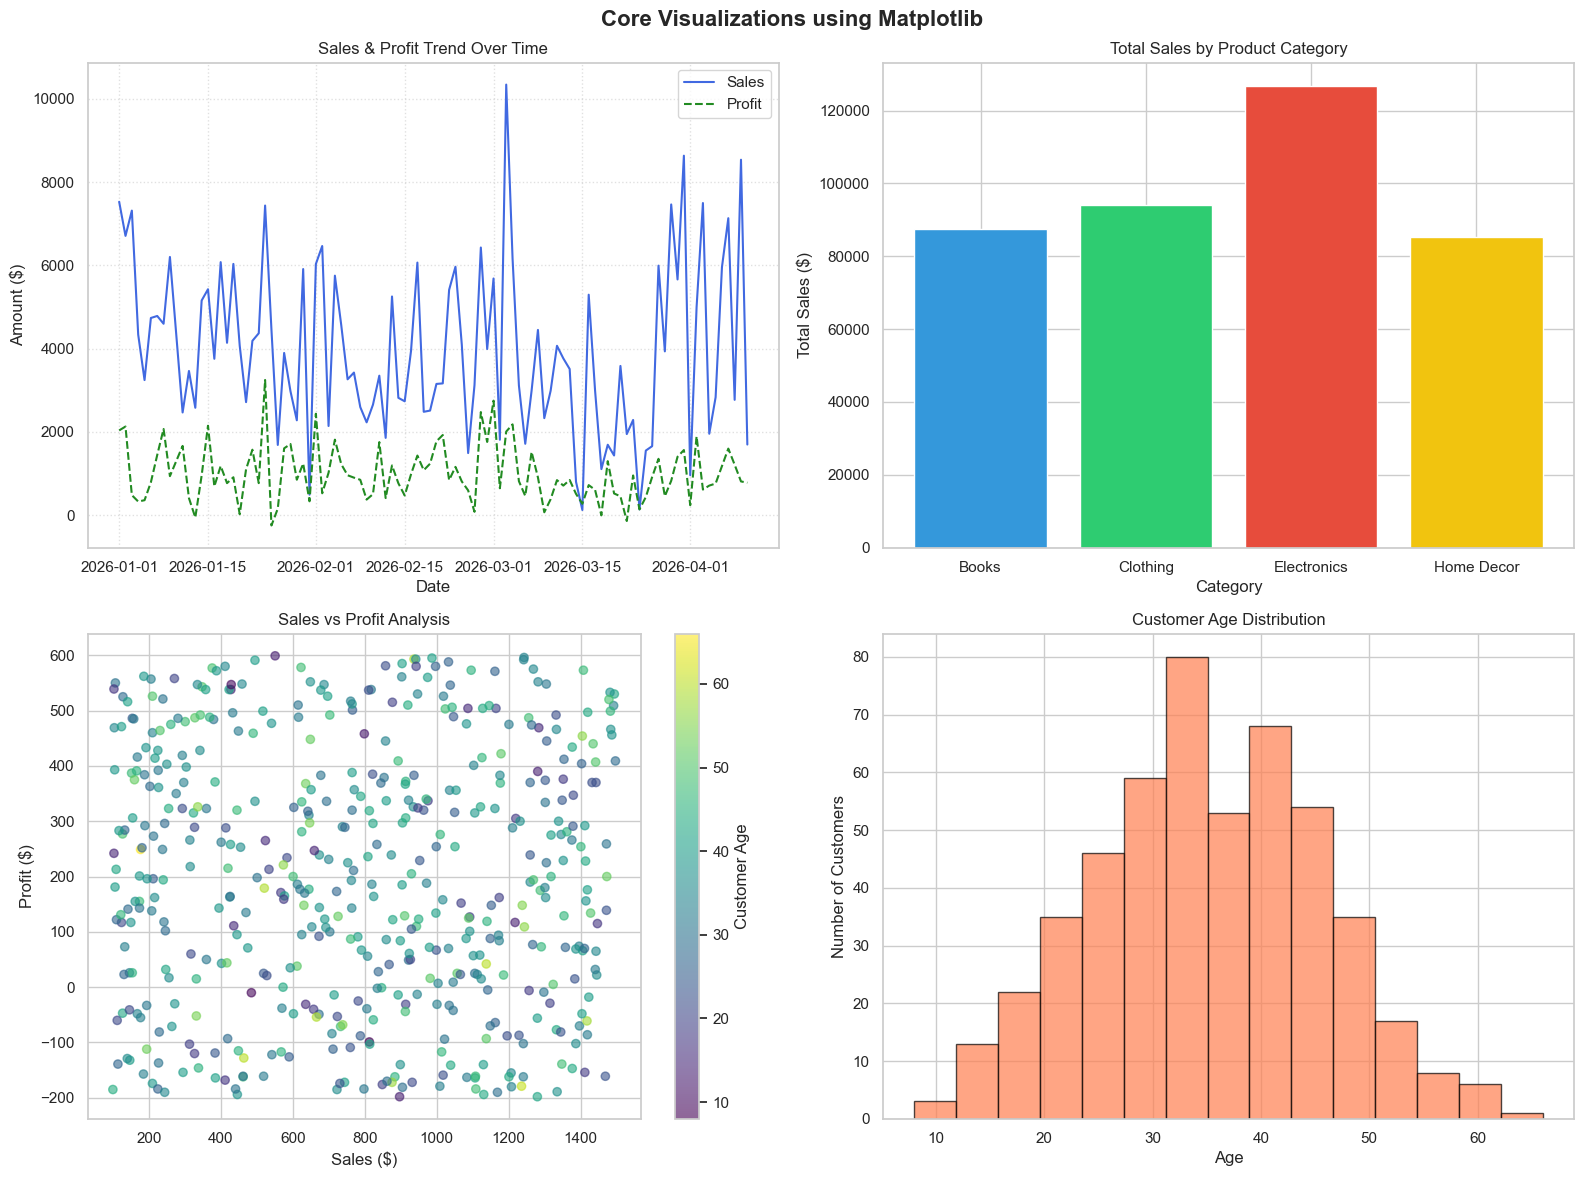

In [24]:
# Setting up a 2x2 subplot framework
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Core Visualizations using Matplotlib', fontsize=16, fontweight='bold')

# 1. Line Plot: Sales & Profit trends over time
axes[0, 0].plot(df_trend['Date'], df_trend['Sales'], color='royalblue', label='Sales')
axes[0, 0].plot(df_trend['Date'], df_trend['Profit'], color='forestgreen', label='Profit', linestyle='--')
axes[0, 0].set_title('Sales & Profit Trend Over Time')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Amount ($)')
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle=':', alpha=0.6)

# 2. Bar Chart: Categorical comparison of sales
axes[0, 1].bar(df_cat['Category'], df_cat['Sales'], color=['#3498db', '#2ecc71', '#e74c3c', '#f1c40f'])
axes[0, 1].set_title('Total Sales by Product Category')
axes[0, 1].set_xlabel('Category')
axes[0, 1].set_ylabel('Total Sales ($)')

# 3. Scatter Plot: Relation between Sales and Profit with Age encoding
scatter = axes[1, 0].scatter(df['Sales'], df['Profit'], c=df['Customer_Age'], cmap='viridis', alpha=0.6)
axes[1, 0].set_title('Sales vs Profit Analysis')
axes[1, 0].set_xlabel('Sales ($)')
axes[1, 0].set_ylabel('Profit ($)')
fig.colorbar(scatter, ax=axes[1, 0], label='Customer Age')

# 4. Histogram: Distribution of customer demographics
axes[1, 1].hist(df['Customer_Age'], bins=15, color='coral', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Customer Age Distribution')
axes[1, 1].set_xlabel('Age')
axes[1, 1].set_ylabel('Number of Customers')

plt.tight_layout()

# Exporting the subplots grid as a high-quality PNG
plt.savefig('matplotlib_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

#### Code (Part 2 - Seaborn Advanced Plots)

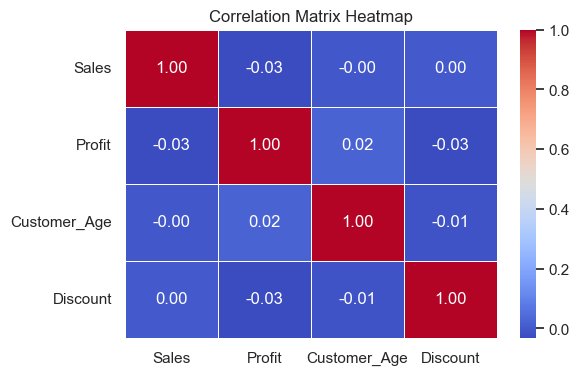

C:\Users\SKHAKH MUBASHSHIR\AppData\Local\Temp\ipykernel_30748\3378023388.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='Category', y='Profit', data=df, palette='Set2')


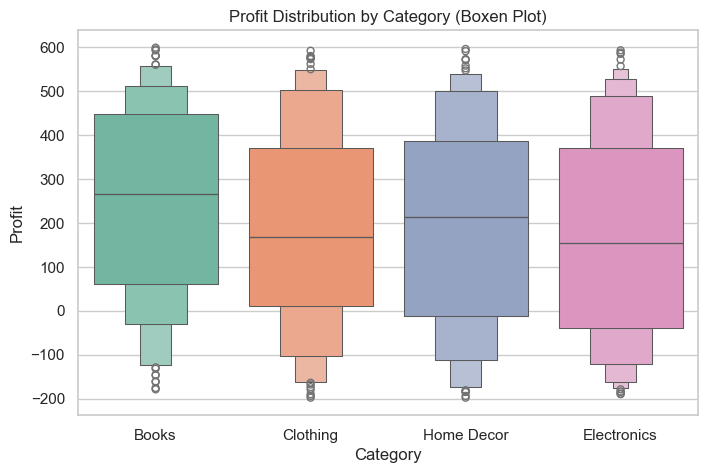

In [25]:
# Applying a clean theme for Seaborn plots
sns.set_theme(style="whitegrid")

# 1. Correlation Matrix Heatmap
plt.figure(figsize=(6, 4))
corr_matrix = df[['Sales', 'Profit', 'Customer_Age', 'Discount']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.savefig('seaborn_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Boxenplot for granular distribution analysis
plt.figure(figsize=(8, 5))
sns.boxenplot(x='Category', y='Profit', data=df, palette='Set2')
plt.title('Profit Distribution by Category (Boxen Plot)')
plt.savefig('seaborn_boxenplot.png', dpi=300, bbox_inches='tight')
plt.show()

#### Code (Part 3 - Seaborn Pairplot)

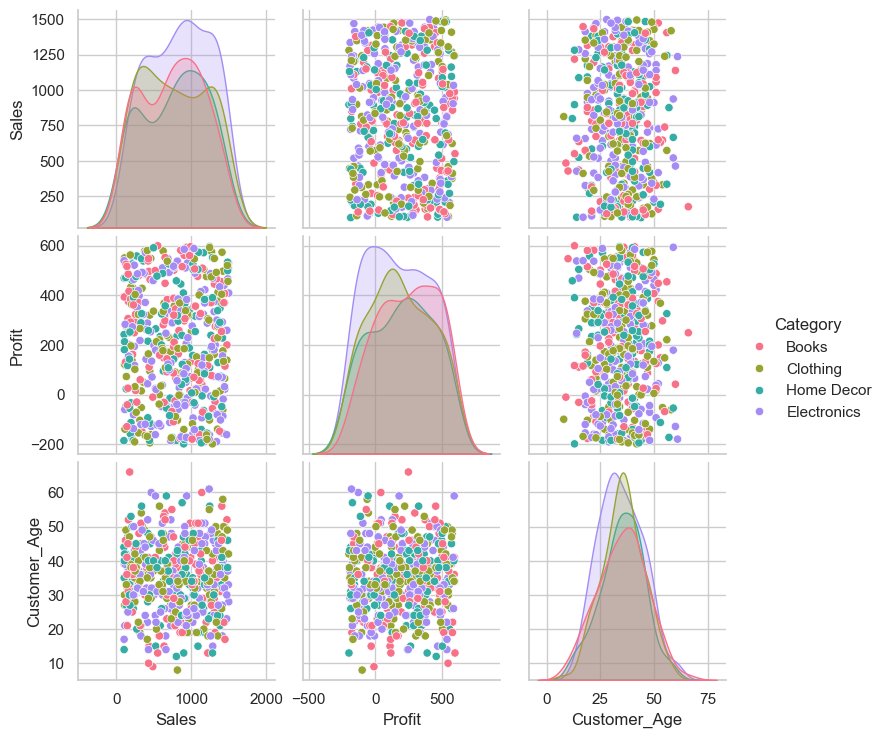

In [27]:
# 3. Pairplot to examine multi-variable relationships across categories
pair_plot = sns.pairplot(df, hue='Category', vars=['Sales', 'Profit', 'Customer_Age'], palette='husl')
pair_plot.savefig('seaborn_pairplot.png', dpi=300)
plt.show()

#### Code (Part 4 - Plotly Interactive Visuals)

In [28]:
# Generating an interactive scatter plot using Plotly Express
fig_plotly = px.scatter(
    df, 
    x="Sales", 
    y="Profit", 
    color="Category", 
    size="Customer_Age",
    hover_data=["Date", "Discount"],
    title="Interactive Sales vs Profit Analysis (Plotly)",
    labels={"Sales": "Sales ($)", "Profit": "Profit ($)"},
    template="plotly_white"
)

# Exporting the plot as a standalone web-ready HTML file
fig_plotly.write_html("plotly_interactive_chart.html")
print("Plotly chart successfully exported as 'plotly_interactive_chart.html'")

# Rendering the interactive view inside the notebook
fig_plotly.show()

Plotly chart successfully exported as 'plotly_interactive_chart.html'


In [32]:
df.to_csv('ecommerce_tableau_data.csv', index=False)